# Set Isoptope and saved emcee sampler path

In [1]:
!nvidia-smi

Wed Jul  2 18:40:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.67                 Driver Version: 550.67         CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:3B:00.0 Off |                  Off |
| 30%   36C    P8             24W /  300W |      29MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [32]:
"""
This loads the corresponding h5 file for emcee based on the configuration
Possible run config data set names:
- 'Flaherty' : Flaherty cube (low res)
- 'Flaherty_NoRBreak_NoVTurb': Flaherty cube with no r_break and no v_turb
- 'Flaherty_sigma_1e-2' : Using 2% peak signal for sigma instead of background sigma
    - 'Flaherty_sigma_1e-2_NoRBreak_NoVTurb' : self explanatory
"""

# dataset = 'Flaherty'
# dataset = 'Flaherty_NoRBreak_NoVTurb'
# dataset = 'Flaherty_sigma_1e-2'
# dataset = 'Flaherty_sigma_1e-2_NoRBreak_NoVTurb'
dataset = 'MAPS'
isotope_name = 'CO'
mcmc_iters = 1900
stride = 3

mcmc_sampler_path = f'/nfs/rhea.dgp/u8/d/len/code/radjax_updated/mcmc_output/runs/{dataset}_{isotope_name}_{mcmc_iters}_iter_stride{stride}_MCMC_sampler/{dataset}_{isotope_name}_{mcmc_iters}_iter_stride{stride}_MCMC_sampler.h5'

# mcmc_sampler_path = '/nfs/rhea.dgp/u8/d/len/code/radjax_updated/notebooks/MAPS_CO_800_iter_sigma7e-3_stride3_MCMC_sampler.h5'

if isotope_name == 'C18O':
    isotope_abundance_factor = 1/557
    isotope_pixel_sigma = 0.00099
elif isotope_name == '13CO':
    isotope_abundance_factor = 1/69
    isotope_pixel_sigma = 0.00143
elif isotope_name == 'CO':
    isotope_abundance_factor = 1
    if dataset == 'MAPS':
        isotope_pixel_sigma = 0.002
    elif dataset =='Flaherty' or dataset == 'Flaherty_NoRBreak_NoVTurb':
        isotope_pixel_sigma = 0.0074
    elif dataset.startswith('Flaherty_sigma_1e-2'):
        isotope_pixel_sigma = 0.01
    else:
        print("Invalid dataset name, can't get sigma.")
else:
    print("Invalid isotope name.")

In [33]:
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from gofish import imagecube
from ruamel.yaml import YAML

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk
from network import shard
from consts import *
import emcee
from functools import partial
import time

def render_cube_pinhole(ray_coords, pixel_area, disk_params, nd_co, temperature, velocity_az, bbox, freqs, nu0, obs_dir, molecular_table):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)

    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)

    # Load molecular data from disk_params
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=molecular_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(
        energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    n_up, n_dn = line_rte.n_up_down(
        gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    alpha_tot = line_rte.alpha_total_co(disk_params['v_turb'], gas_t)

    print(f'computing pinhole spectral cube for a total of {freqs.size} frequencies')
    print(f'From {freqs.min()} to {freqs.max()}')
    images = line_rte.compute_spectral_cube_pmap(
        shard(freqs), gas_v, alpha_tot, n_up, n_dn,
        a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
    )
    images = np.nan_to_num(images).reshape(freqs.size, *ray_coords.shape[:2])
    return images

disk_params_flaherty = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=isotope_abundance_factor*1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk_params_flaherty['r_in'], 800
z_disk, r_disk = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution), 
    jnp.linspace(r_min, r_max, resolution), 
    indexing='ij'
)
molecular_table = "/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"

temperature_flaherty = parametric_disk.temperature_profile(z_disk, r_disk, disk_params_flaherty)

nd_h2_flaherty = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature_flaherty,
    disk_params_flaherty['gamma'],
    disk_params_flaherty['r_in'],
    10 ** disk_params_flaherty['log_r_c'],
    disk_params_flaherty['M_gas'],
    disk_params_flaherty['M_star'],
    disk_params_flaherty['m_mol']
)

velocity_az_flaherty = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2_flaherty, 
    temperature_flaherty, 
    disk_params_flaherty
)

N_h2_flaherty = parametric_disk.surface_density(z_disk, nd_h2_flaherty)

abundance_co_flaherty = parametric_disk.co_abundance_profile(N_h2_flaherty, temperature_flaherty, disk_params_flaherty)
nd_co_flaherty = abundance_co_flaherty * nd_h2_flaherty

bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])

# Load observation data from CLEAN cube

In [34]:
if dataset == 'MAPS':
    fov_as = 10.0  # arcsecs
    # data_path = '~/code/radjax/data/alma/HD163296_CO_highres_cen.cm.fits'
    data_path = f'/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_{isotope_name}_220GHz.0.2arcsec.image.fits'
    velocity_range = (2000, 10000) # m/s
    vlsr = 5770 
    
    data_cube = imagecube(data_path, FOV=fov_as, velocity_range=velocity_range)
    
    nu0 = data_cube.nu0  # e.g. 230.538 GHz
    freqs = data_cube.velocity_to_restframe_frequency(vlsr=vlsr)
    velocities = data_cube.velax
    data = data_cube.data
    x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
    npix = data_cube.nxpix
elif dataset.startswith('Flaherty'):
    fov_as = 11.0  # arcsecs
    data_path = f'/scratch/ondemand28/len/data/radjax/flaherty/HD163296_{isotope_name}_highres_cen.cm.fits'
    # data_path = '/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_CO_220GHz.0.2arcsec.image.fits'
    data_cube = imagecube(data_path,FOV=fov_as)

    num_freqs_resample = 60
    num_freqs = len(data_cube.freqax)
    idx = np.round(np.linspace(0, num_freqs - 1, num_freqs_resample)).astype(int)

    data = data_cube.data[idx]
    freqs = data_cube.freqax[idx]
    velocities = data_cube.velax[idx]
    nu0 = data_cube.nu0  # e.g. 230.538 GHz
    
    freqs += nu0 - freqs.mean()
    x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')

npix = data_cube.nxpix

projection_pinhole = sensor.PinholeProjection(
    name=f'HD163296_{isotope_name}',
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs
)

fov_rad = fov_as * arcsec
fov = 2 * projection_pinhole.distance * pc * np.tan(fov_rad / 2.0)
pixel_area_pinhole = (fov / npix) ** 2

ray_coords_pinhole, obs_dir_pinhole = sensor.pinhole_disk_projection(
    projection_pinhole.x_sky,
    projection_pinhole.y_sky,
    projection_pinhole.distance,
    projection_pinhole.nray,
    projection_pinhole.incl,
    projection_pinhole.phi,
    projection_pinhole.posang,
    projection_pinhole.z_width
)

beam = data_cube.beams_per_pix * sensor.beam(
    data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa
)

In [35]:
images_flaherty = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params_flaherty,
    nd_co_flaherty,
    temperature_flaherty,
    -velocity_az_flaherty,  # note sign convention
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)
images_flaherty_blurred = sensor.fftconvolve_vmap(images_flaherty, beam)


computing pinhole spectral cube for a total of 40 frequencies
From 230534854901.87387 to 230540852888.53104


In [36]:
data.max()

np.float32(0.10299241)

In [37]:
import inference

backend = emcee.backends.HDFBackend(mcmc_sampler_path)
samples = backend.get_chain(flat=True)

discard_steps = int(3*backend.iteration//4) 
flat_samples = backend.get_chain(discard=discard_steps, thin=1, flat=True)

ndim = flat_samples.shape[-1]

param_index_dict = inference.DISK_PARAM_INDEX
posterior_params = {
    param_index_dict['q']: {
        'bounds': [-0.5, 0.0],
        'p0_range': [-0.3, -0.1],
    },
    param_index_dict['log_r_c']: {
        'bounds': [1.75, 2.50],
        'p0_range': [2.00, 2.30],
    },
    param_index_dict['v_turb']: {
        'bounds': [0.0, 1.0],
        'p0_range': [0.05, 0.15],
    },
    param_index_dict['T_atm1']: {
        'bounds': [40.0, 150.0],
        'p0_range': [60.0, 110.0],
    },
    param_index_dict['T_mid1']: {
        'bounds': [5.0, 40.0],
        'p0_range': [10.0, 30.0],
    },
    param_index_dict['r_in']: {
        'bounds': [1.0, 20.0],
        'p0_range': [5.0, 15.0],
    },
    param_index_dict['r_break']: {
        'bounds': [15.0, 115.0],
        'p0_range': [50.0, 80.0],
    },
    param_index_dict['q_in']: {
        'bounds': [-1.0, 0.0],
        'p0_range': [-0.7, -0.3],
    }
}

param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

chosen_values = np.median(flat_samples, axis=0)
print("Chosen parameter values (from MCMC) with their Flaherty's values:")

for label, value in zip(param_labels, chosen_values):
#     disk_params[label] = value
    print(f"{label} = {value:.4f} (vs. Flaherty's: {disk_params_flaherty[label]})")

disk_params_mcmc = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=isotope_abundance_factor*1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

for label, value in zip(param_labels, chosen_values):
    disk_params_mcmc[label] = value
    print(f"Diskparam MCMC for {label} updated to: {disk_params_mcmc[label]}")

print("Updated disk_params_MCMC:\n",disk_params_mcmc)
# # Update the disk_params with the MCMC results
# disk_params['v_turb'] = chosen_values[param_index_dict['v_turb']]
# disk_params['T_mid1'] = chosen_values[param_index_dict['T_mid1']]
# disk_params['T_atm1'] = chosen_values[param_index_dict['T_atm1']]
# disk_params['q'] = chosen_values[param_index_dict['q']]
# disk_params['q_in'] = chosen_values[param_index_dict['q_in']]
# disk_params['r_break'] = chosen_values[param_index_dict['r_break']]
# disk_params['r_in'] = chosen_values[param_index_dict['r_in']]
# disk_params['log_r_c'] = chosen_values[param_index_dict['log_r_c']]



Chosen parameter values (from MCMC) with their Flaherty's values:
T_mid1 = 18.3335 (vs. Flaherty's: 17.8)
T_atm1 = 62.3659 (vs. Flaherty's: 87.0)
q = -0.2079 (vs. Flaherty's: -0.27)
q_in = -0.3660 (vs. Flaherty's: -0.57)
r_break = 86.8639 (vs. Flaherty's: 70)
r_in = 19.9031 (vs. Flaherty's: 11.0)
log_r_c = 2.2128 (vs. Flaherty's: 2.3)
v_turb = 0.1743 (vs. Flaherty's: 0.06)
Diskparam MCMC for T_mid1 updated to: 18.333492405695353
Diskparam MCMC for T_atm1 updated to: 62.365899314998316
Diskparam MCMC for q updated to: -0.20787631768811296
Diskparam MCMC for q_in updated to: -0.3660324019616817
Diskparam MCMC for r_break updated to: 86.86391107203099
Diskparam MCMC for r_in updated to: 19.90314390084131
Diskparam MCMC for log_r_c updated to: 2.2127993716281225
Diskparam MCMC for v_turb updated to: 0.17431645519716904
Updated disk_params_MCMC:
 {'T_mid1': np.float64(18.333492405695353), 'T_atm1': np.float64(62.365899314998316), 'q': np.float64(-0.20787631768811296), 'q_in': np.float64(-0.

Flat samples shape: (24000, 8)


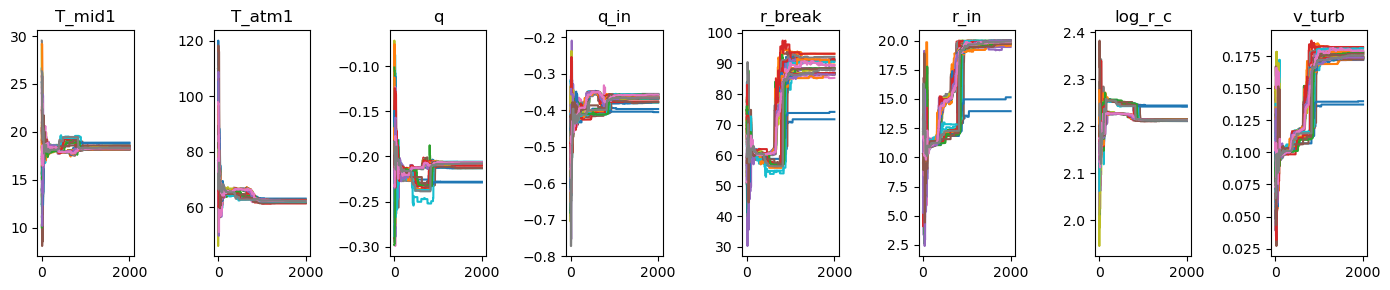

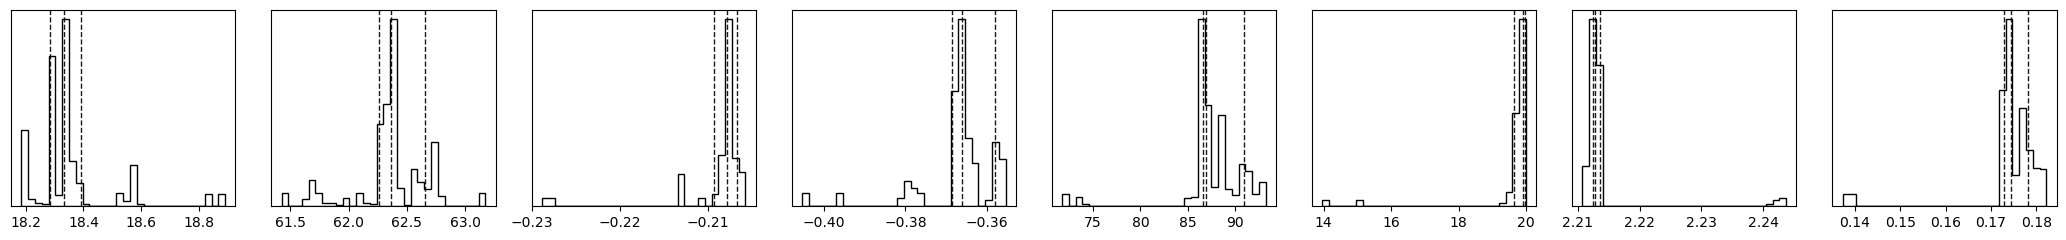

In [38]:
ground_truth = {
    "q": -0.27,
    "log_r_c": 2.3,
    "v_turb": 0.06,
    "T_atm1": 87.0,
    "T_mid1": 17.8,
    "r_in": 11.0,
    "r_break": 70.0,
    "q_in": -0.57
}

chain = backend.get_chain()

fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_labels[i])

plt.tight_layout()

import corner

print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)


truth_values = [ground_truth[label] for label in param_labels]

# corner plot
# fig = corner.corner(
#     flat_samples,
#     labels=param_labels,
#     quantiles=[0.16, 0.5, 0.84],
#     show_titles=True,
#     truths=truth_values,        # <--- overlay true values
#     truth_color="red",          # optional color
#     title_kwargs={"fontsize": 12}
# )

from scipy.stats import gaussian_kde

# Config
quantiles = [16, 50, 84]
n_params = len(param_labels)
fig, axes = plt.subplots(1, n_params, figsize=(2.6 * n_params, 2.5), sharey=False)

for i, label in enumerate(param_labels):
    ax = axes[i]
    data_p = flat_samples[:, i]

    # Histogram
    ax.hist(data_p, bins=30, density=True, histtype='stepfilled',
        facecolor='white', lw=1, color='white', edgecolor='k')

    # KDE
#     kde = gaussian_kde(data)
#     x_vals = np.linspace(data.min(), data.max(), 1000)
#     ax.plot(x_vals, kde(x_vals), color='C0')

    # Quantiles
    q16, q50, q84 = np.percentile(data_p, quantiles)
    ax.axvline(q16, color='k', ls='--', lw=1, alpha=0.9)
    ax.axvline(q50, color='k', ls='--', lw=1, alpha=0.9)
    ax.axvline(q84, color='k', ls='--', lw=1, alpha=0.9)

    # Ground truth (optional)
#     if label in ground_truth:
#         ax.axvline(ground_truth[label], color='red', ls=':', lw=1)

#     ax.set_xlabel(label)
    ax.set_yticks([])
    ax.set_ylabel('')
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [39]:
import pandas as pd
import numpy as np

quantiles = [16, 50, 84]
summary_rows = []

for i, label in enumerate(param_labels):
    samples = flat_samples[:, i]
    q16, q50, q84 = np.percentile(samples, quantiles)
    err_minus = q50 - q16
    err_plus = q84 - q50

    flaherty_val = ground_truth.get(label, np.nan)

    summary_rows.append({
        "Parameter": label,
        "Flaherty": flaherty_val,
        "MCMC Median": f"{q50:.4f}",
        "MCMC +Err": f"{err_plus:.4f}",
        "MCMC -Err": f"{err_minus:.4f}"
        
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))


quantiles = [16, 50, 84]
latex_labels = {
    "T_mid1": r"$T_\mathrm{mid1}$ [K]",
    "T_atm1": r"$T_\mathrm{atm1}$ [K]",
    "q": r"$q$",
    "q_in": r"$q_\mathrm{in}$",
    "r_break": r"$r_\mathrm{break}$ [au]",
    "r_in": r"$r_\mathrm{in}$ [au]",
    "log_r_c": r"$\log_{10}(r_c)$ [au]",
    "v_turb": r"$v_\mathrm{turb}$ [$c_s$]"
}

# Flaherty values
flaherty_vals = {
    "T_mid1": "17.8",
    "T_atm1": "87.0",
    "q": "-0.27",
    "q_in": "-0.57",
    "r_break": "70.0",
    "r_in": "11.0",
    "log_r_c": "2.326",
    "v_turb": "< 0.06"
}

for i, param in enumerate(param_labels):
    samples = flat_samples[:, i]
    q16, q50, q84 = np.percentile(samples, quantiles)
    err_minus = q50 - q16
    err_plus = q84 - q50

    param_latex = latex_labels[param]
    fl_val = flaherty_vals.get(param, "---")
    mcmc_val = f"${q50:.3f}^{{+{err_plus:.3f}}}_{{-{err_minus:.3f}}}$"

    print(f"{param_latex} & ${fl_val}$ & {mcmc_val} & [TODO MAPS value] \\\\")

Parameter  Flaherty MCMC Median MCMC +Err MCMC -Err
   T_mid1     17.80     18.3335    0.0589    0.0493
   T_atm1     87.00     62.3659    0.2896    0.1039
        q     -0.27     -0.2079    0.0012    0.0015
     q_in     -0.57     -0.3660    0.0080    0.0025
  r_break     70.00     86.8639    4.0480    0.3005
     r_in     11.00     19.9031    0.0699    0.2459
  log_r_c      2.30      2.2128    0.0008    0.0003
   v_turb      0.06      0.1743    0.0038    0.0015
$T_\mathrm{mid1}$ [K] & $17.8$ & $18.333^{+0.059}_{-0.049}$ & [TODO MAPS value] \\
$T_\mathrm{atm1}$ [K] & $87.0$ & $62.366^{+0.290}_{-0.104}$ & [TODO MAPS value] \\
$q$ & $-0.27$ & $-0.208^{+0.001}_{-0.001}$ & [TODO MAPS value] \\
$q_\mathrm{in}$ & $-0.57$ & $-0.366^{+0.008}_{-0.003}$ & [TODO MAPS value] \\
$r_\mathrm{break}$ [au] & $70.0$ & $86.864^{+4.048}_{-0.301}$ & [TODO MAPS value] \\
$r_\mathrm{in}$ [au] & $11.0$ & $19.903^{+0.070}_{-0.246}$ & [TODO MAPS value] \\
$\log_{10}(r_c)$ [au] & $2.326$ & $2.213^{+0.001}_{-0.0

Saved → mcmc_minimal_dump.npz


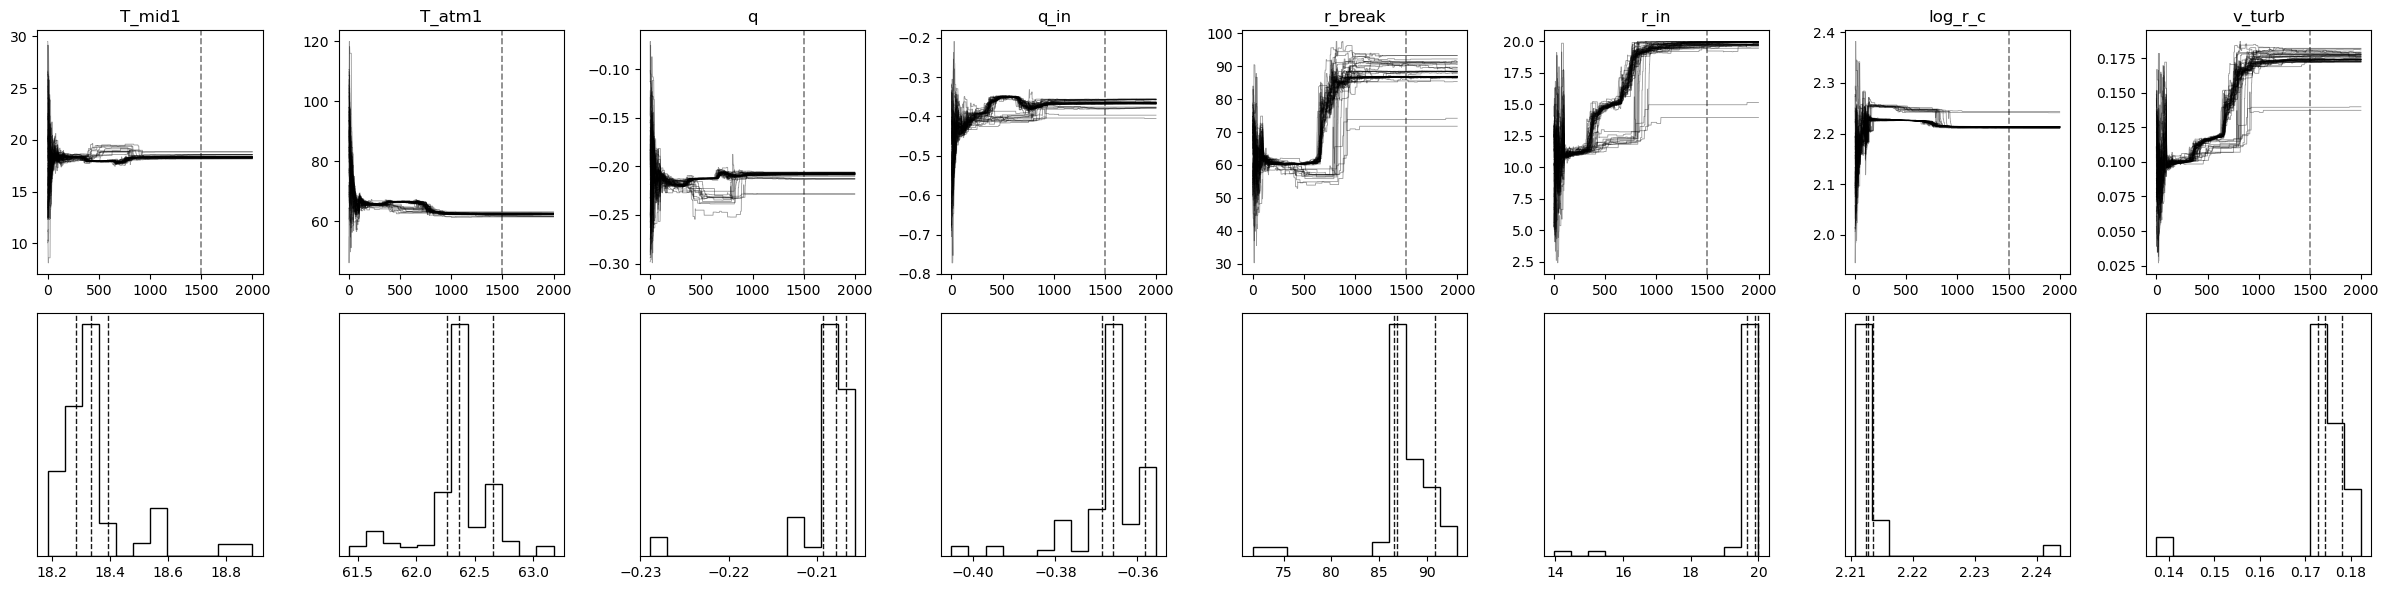

In [40]:
quantiles = [16, 50, 84]
n_params = len(param_labels)

fig, axes = plt.subplots(2, n_params, figsize=(3 * n_params, 6))
if n_params == 1:
    axes = axes.reshape(2, 1)  # one param case

for i, label in enumerate(param_labels):
    # Top: Walker plot
    ax_trace = axes[0, i]
    for walker in chain[:, :, i].T:
        ax_trace.plot(walker, alpha=0.4, lw=0.6, color='black')
    ax_trace.axvline(discard_steps, color='k', ls='--', lw=1.2, alpha=0.5)  # vertical line
    ax_trace.set_title(label)

    # Bottom: Histogram
    ax_hist = axes[1, i]
    data_p = flat_samples[:, i]
    ax_hist.hist(
        data_p, bins=12, density=True, histtype='stepfilled',
        facecolor='white', lw=1, color='white', edgecolor='k'
    )

    q16, q50, q84 = np.percentile(data_p, quantiles)
    for q in (q16, q50, q84):
        ax_hist.axvline(q, color='k', ls='--', lw=1, alpha=0.9)
        
    ax_hist.set_yticks([])

    
# Saved necessary data to plot using a local notebook
# Cluster doesn't have LaTeX support for matplotlib
np.savez(
    f"/nfs/rhea.dgp/u8/d/len/code/radjax_updated/mcmc_output/runs/{dataset}_{isotope_name}_{mcmc_iters}_iter_stride{stride}_MCMC_sampler/mcmc_minimal_dump.npz",
    chain=chain.astype(np.float32),          # walkers, steps, parameters
    flat_samples=flat_samples.astype(np.float32),
    param_labels=np.array(param_labels),     # list → 1-D object array
    discard_steps=np.asarray(discard_steps), # scalar → 0-D array
)

print("Saved → mcmc_minimal_dump.npz")

plt.savefig(f'/nfs/rhea.dgp/u8/d/len/code/radjax_updated/mcmc_output/runs/{dataset}_{isotope_name}_{mcmc_iters}_iter_stride{stride}_MCMC_sampler/mcmc_chain.svg', format='svg',dpi=300)
# plt.savefig('/nfs/rhea.dgp/u8/d/len/code/radjax_updated/figures/mcmc_chain.svg', format='svg',dpi=300)
plt.tight_layout()
plt.show()

computing pinhole spectral cube for a total of 40 frequencies
From 230534854901.87387 to 230540852888.53104


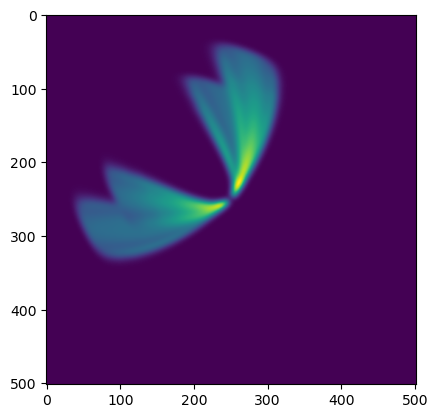

In [41]:
# # Recompute temperature and densities 
temperature_mcmc = parametric_disk.temperature_profile(z_disk, r_disk, disk_params_mcmc)
nd_h2_mcmc = parametric_disk.number_density_profile(
    z_disk,
    r_disk,
    temperature_mcmc,
    disk_params_mcmc["gamma"],
    disk_params_mcmc["r_in"],
    10 ** disk_params_mcmc["log_r_c"],
    disk_params_mcmc["M_gas"],
    disk_params_mcmc["M_star"],
    disk_params_mcmc["m_mol"]
)

r_min_mcmc, r_max_mcmc = disk_params_mcmc['r_in'], 800
z_disk_mcmc, r_disk_mcmc = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution), 
    jnp.linspace(r_min_mcmc, r_max_mcmc, resolution), 
    indexing='ij'
)

velocity_az_mcmc = -parametric_disk.velocity_profile(
    z_disk, r_disk_mcmc, nd_h2_mcmc, temperature_mcmc, disk_params_mcmc
)

N_h2_mcmc = parametric_disk.surface_density(z_disk, nd_h2_mcmc)
abundance_co_mcmc = parametric_disk.co_abundance_profile(N_h2_mcmc, temperature_mcmc, disk_params_mcmc)
nd_co_mcmc = abundance_co_mcmc * nd_h2_mcmc

bbox_disk_mcmc = jnp.array([(au*z_min, au*z_max), (au*r_min_mcmc, au*r_max_mcmc)])

projection_pinhole_mcmc = sensor.PinholeProjection(
    name=f'HD163296_{isotope_name}_MCMC',
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs
)

fov_rad = fov_as * arcsec
fov = 2 * projection_pinhole_mcmc.distance * pc * np.tan(fov_rad / 2.0)
pixel_area_pinhole_mcmc = (fov / npix) ** 2

ray_coords_pinhole_mcmc, obs_dir_pinhole_mcmc = sensor.pinhole_disk_projection(
    projection_pinhole_mcmc.x_sky,
    projection_pinhole_mcmc.y_sky,
    projection_pinhole_mcmc.distance,
    projection_pinhole_mcmc.nray,
    projection_pinhole_mcmc.incl,
    projection_pinhole_mcmc.phi,
    projection_pinhole_mcmc.posang,
    projection_pinhole_mcmc.z_width
)

beam = data_cube.beams_per_pix * sensor.beam(
    data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa
)

# # Render new cube with the updated v_turb
images_mcmc = render_cube_pinhole(
    ray_coords=ray_coords_pinhole_mcmc,
    pixel_area=pixel_area_pinhole_mcmc,
    disk_params=disk_params_mcmc,       # pass the dictionary instead of a disk object
    nd_co=nd_co_mcmc,
    temperature=temperature_mcmc,
    velocity_az=velocity_az_mcmc,
    bbox=bbox_disk_mcmc,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole_mcmc,
    molecular_table=molecular_table
)

images_mcmc_blurred = sensor.fftconvolve_vmap(images_mcmc, beam)

plt.imshow(images_mcmc_blurred[15])

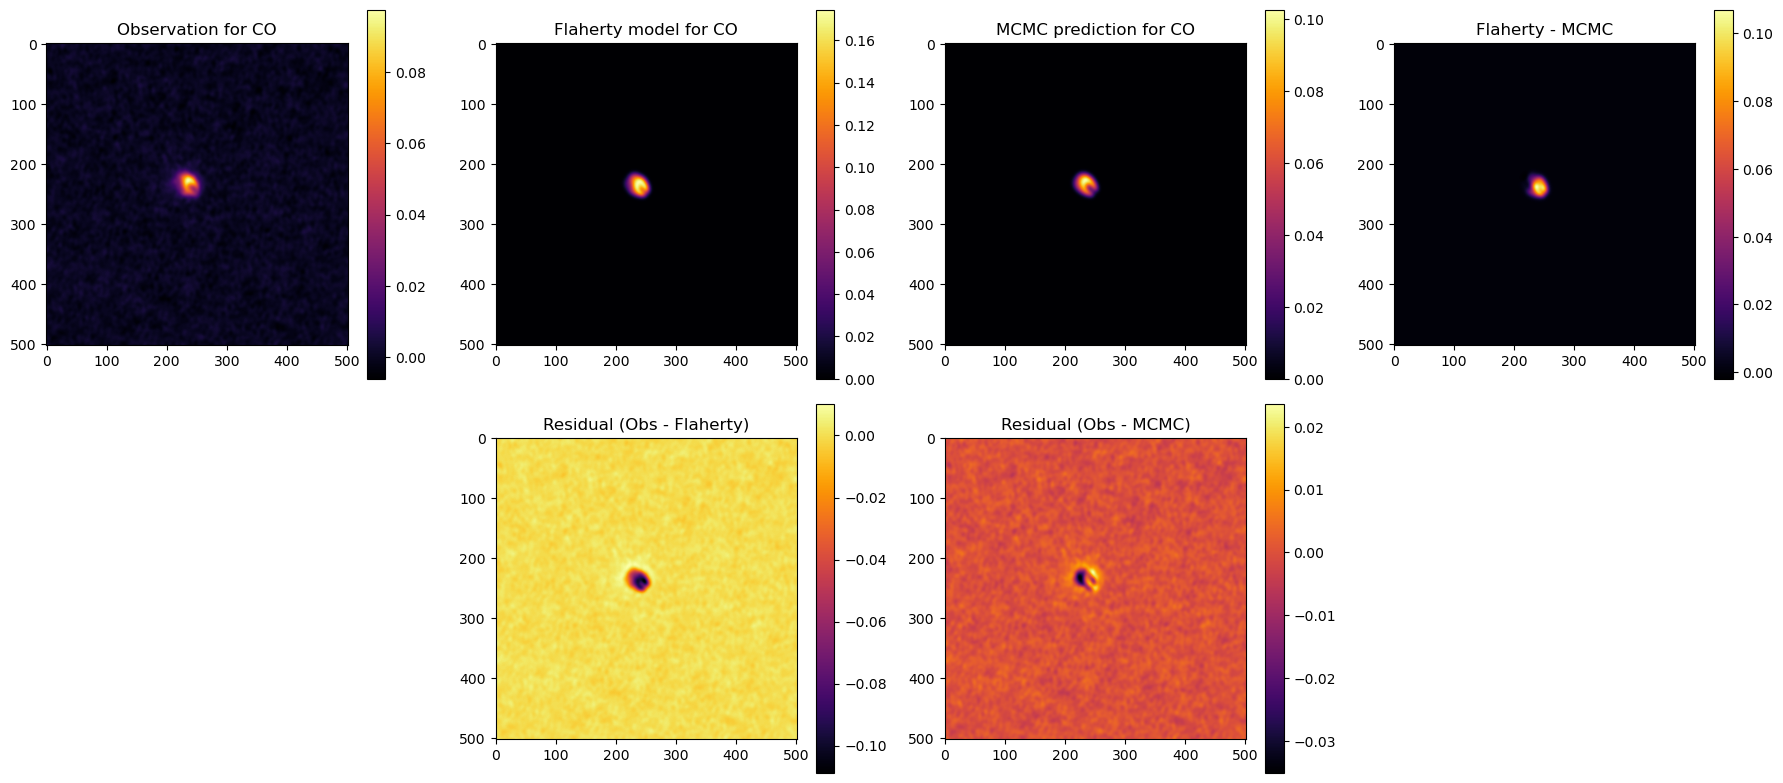

In [42]:
import matplotlib.pyplot as plt

img_index = 0

# Compute residuals
residual_flaherty = data[img_index] - images_flaherty_blurred[img_index]
residual_mcmc = data[img_index] - images_mcmc_blurred[img_index]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Observation
im0 = axes[0, 0].imshow(data[img_index], cmap='inferno')
axes[0, 0].set_title(f'Observation for {isotope_name}')
plt.colorbar(im0, ax=axes[0, 0], orientation='vertical')

# Flaherty model prediction
im1 = axes[0, 1].imshow(images_flaherty_blurred[img_index], cmap='inferno')
axes[0, 1].set_title(f'Flaherty model for {isotope_name}')
plt.colorbar(im1, ax=axes[0, 1], orientation='vertical')

# MCMC prediction
im2 = axes[0, 2].imshow(images_mcmc_blurred[img_index], cmap='inferno')
axes[0, 2].set_title(f'MCMC prediction for {isotope_name}')
plt.colorbar(im2, ax=axes[0, 2], orientation='vertical')

# Residual (Observation - Flaherty)
im3 = axes[1, 1].imshow(residual_flaherty, cmap='inferno')
axes[1, 1].set_title('Residual (Obs - Flaherty)')
plt.colorbar(im3, ax=axes[1, 1], orientation='vertical')

# Residual (Observation - MCMC)
im4 = axes[1, 2].imshow(residual_mcmc, cmap='inferno')
axes[1, 2].set_title('Residual (Obs - MCMC)')
plt.colorbar(im4, ax=axes[1, 2], orientation='vertical')

im5 = axes[0, 3].imshow(images_flaherty_blurred[img_index] - images_mcmc_blurred[img_index], cmap='inferno')
axes[0, 3].set_title('Flaherty - MCMC')
plt.colorbar(im5, ax=axes[0, 3], orientation='vertical')

# Hide the unused bottom-left subplot
axes[1, 0].axis('off')
# Hide the unused bottom-left subplot
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()


In [43]:
import numpy as np

# Flaherty residuals
residual_flahery = data - images_flaherty_blurred
chi2_flahery = np.sum(((residual_flahery) / isotope_pixel_sigma)**2)
residual_sum_flahery = np.sum(np.abs(residual_flahery))
residual_mean_flahery = np.mean(np.abs(residual_flahery))
rmse_flahery = np.sqrt(np.mean(residual_flahery**2))

# Number of fitted parameters
k = len(posterior_params)  # or use your fixed value
sigma = isotope_pixel_sigma

# Reduced chi-squared
flaherty_reduced_chi_squared = np.mean((residual_flahery / sigma)**2) / k

print(f"Flaherty Chi-squared: {chi2_flahery:.2f}")
print(f"Flaherty Reduced Chi-squared: {flaherty_reduced_chi_squared:.5f}")
print(f"Flaherty Residual Sum: {residual_sum_flahery:.2f}")
print(f"Flaherty Residual Mean: {residual_mean_flahery:.4f}")
print(f"Flaherty RMSE: {rmse_flahery:.4f}")

# MCMC residuals
residual_mcmc = data - images_mcmc_blurred
chi2_mcmc = np.sum(((residual_mcmc) / isotope_pixel_sigma)**2)
residual_sum_mcmc = np.sum(np.abs(residual_mcmc))
residual_mean_mcmc = np.mean(np.abs(residual_mcmc))
rmse_mcmc = np.sqrt(np.mean(residual_mcmc**2))

# Reduced chi-squared
mcmc_reduced_chi_squared = np.mean((residual_mcmc / sigma)**2) / k

print(f"MCMC Chi-squared: {chi2_mcmc:.2f}")
print(f"MCMC Reduced Chi-squared: {mcmc_reduced_chi_squared:.5f}")
print(f"MCMC Residual Sum: {residual_sum_mcmc:.2f}")
print(f"MCMC Residual Mean: {residual_mean_mcmc:.4f}")
print(f"MCMC RMSE: {rmse_mcmc:.4f}")


Flaherty Chi-squared: 77841718.79
Flaherty Reduced Chi-squared: 0.96528
Flaherty Residual Sum: 25901.73
Flaherty Residual Mean: 0.0026
Flaherty RMSE: 0.0056
MCMC Chi-squared: 32770012.55
MCMC Reduced Chi-squared: 0.40637
MCMC Residual Sum: 21531.12
MCMC Residual Mean: 0.0021
MCMC RMSE: 0.0036


In [44]:
residual_mean_flahery

np.float64(0.0025695751530607977)

In [6]:
mcmc_sampler_path

'/nfs/rhea.dgp/u8/d/len/code/radjax_updated/mcmc_output/runs/MAPS_CO_1900_iter_stride3_MCMC_sampler/MAPS_CO_1900_iter_stride3_MCMC_sampler.h5'

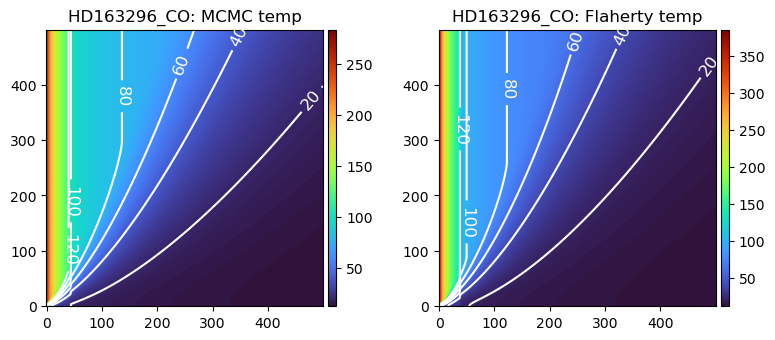

In [29]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
levels = [20, 40, 60, 80, 100, 120]
fig, axes = plt.subplots(1, 2, figsize=(8,3.5))
titles = ['{}: MCMC temp', '{}: Flaherty temp']
images = [temperature_mcmc, temperature_flaherty]
for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, origin='lower', cmap='turbo')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='3%', pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cp = ax.contour(img, levels, colors='white')
    ax.clabel(cp, levels, inline=1, fontsize=12);
    ax.set_title(title.format(projection_pinhole.name))
plt.tight_layout()

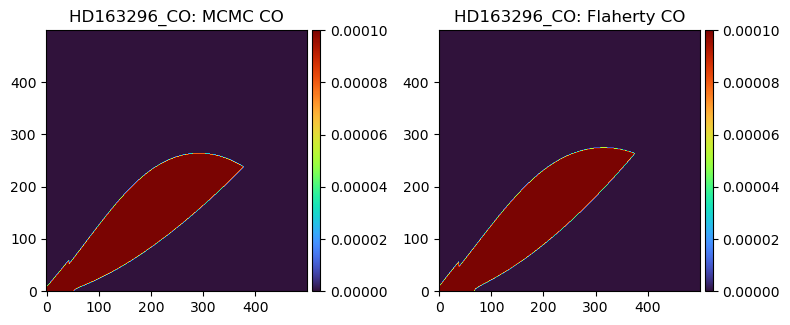

In [30]:
levels = [20, 40, 60, 80, 100, 120]
fig, axes = plt.subplots(1, 2, figsize=(8,3.5))
titles = ['{}: MCMC CO', '{}: Flaherty CO']
images = [abundance_co_mcmc, abundance_co_flaherty]
for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, origin='lower', cmap='turbo')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='3%', pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cp = ax.contour(img, levels, colors='white')
    ax.clabel(cp, levels, inline=1, fontsize=12);
    ax.set_title(title.format(projection_pinhole.name))
plt.tight_layout()

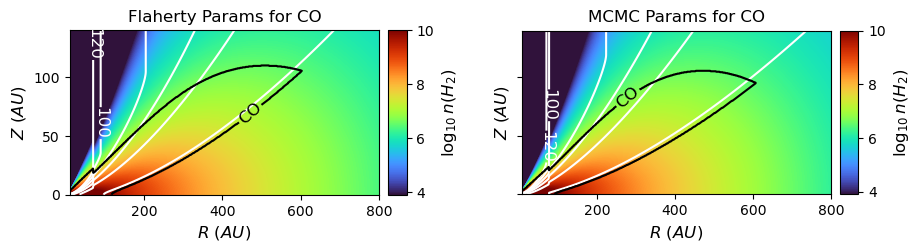

In [31]:
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2_flaherty), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);

divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature_flaherty, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co_flaherty, levels=[disk_params_flaherty['co_abundance']/2], colors='black')
axes[0].clabel(cp, levels=[disk_params_flaherty['co_abundance']/2], fmt='CO', inline=1, fontsize=12);
# cp = axes[0].contour(r_disk, z_disk, N_h2 * m_h, levels=[0.01, 0.1], colors='black', linestyles='dotted')

im = axes[1].imshow(np.log10(nd_h2_mcmc), origin='lower', cmap='turbo', extent=[r_disk_mcmc.min(), r_disk_mcmc.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);

divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[1].contour(r_disk_mcmc, z_disk, temperature_mcmc, levels, colors='white')
axes[1].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[1].contour(r_disk_mcmc, z_disk, abundance_co_mcmc, levels=[disk_params_mcmc['co_abundance']/2], colors='black')
axes[1].clabel(cp, levels=[disk_params_mcmc['co_abundance']/2], fmt='CO', inline=1, fontsize=12);
# cp = axes[0].contour(r_disk, z_disk, N_h2 * m_h, levels=[0.01, 0.1], colors='black', linestyles='dotted')


for ax in axes:
    ax.set_xlabel(r'$R~(AU)$', fontsize=12)
    ax.set_ylabel(r'$Z~(AU)$', fontsize=12)
#     ax.set_xlim(r_disk.min(),500)
    ax.set_ylim(0,140)

axes[0].set_title(f'Flaherty Params for {isotope_name}')
axes[0].set_xlim(r_disk.min(), r_disk.max())
axes[1].set_xlim(r_disk_mcmc.min(), r_disk_mcmc.max())
axes[1].set_title(f'MCMC Params for {isotope_name}')
plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

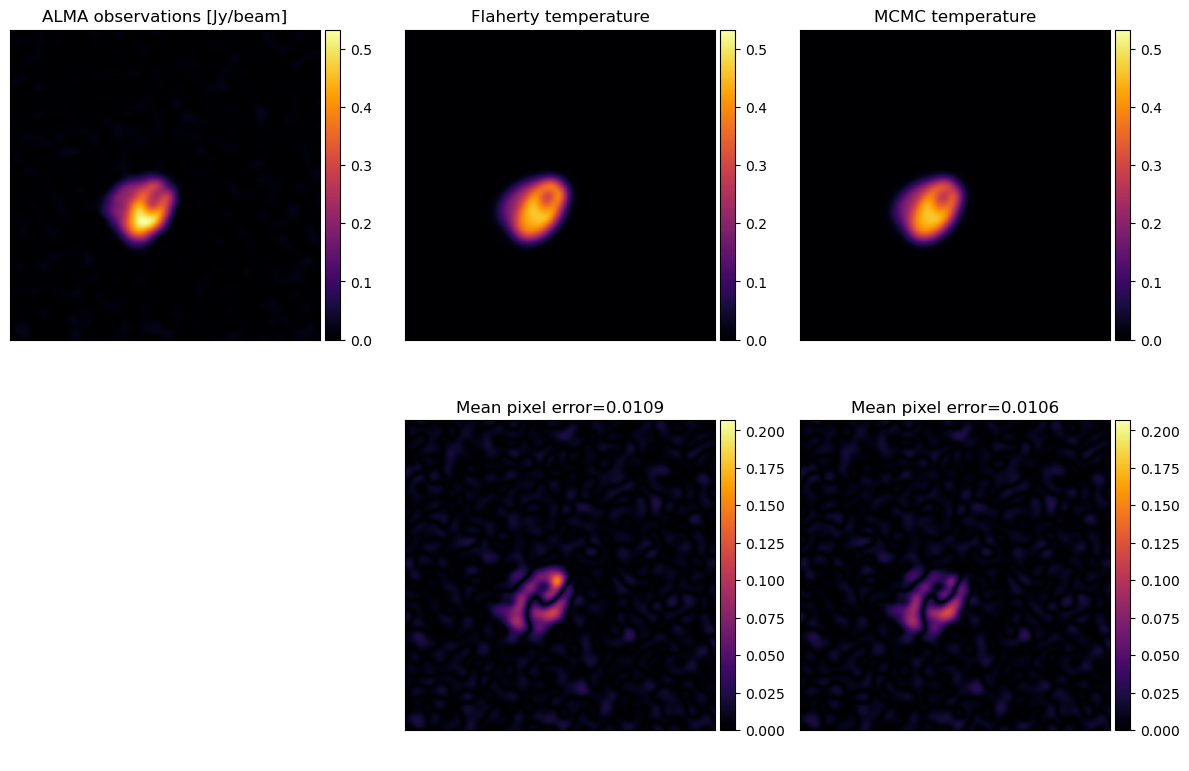

In [32]:
output = mcmc_sampler_path[:-2] +'gif'

fig, axes = plt.subplots(2,3,figsize=(12,8))
axes[1,0].axis("off")
axes_list = list(axes[0]) + list(axes[1,1:])

data_fit_flaherty = np.abs(data - images_flaherty_blurred).mean()
data_fit_mcmc = np.abs(data - images_mcmc_blurred).mean()
titles = [r'ALMA observations [Jy/beam]', 'Flaherty temperature', 'MCMC temperature',
          r'Mean pixel error={:1.4f}'.format(data_fit_flaherty), r'Mean pixel error={:1.4f}'.format(data_fit_mcmc)]
movies = [data, np.array(images_flaherty_blurred), np.array(images_mcmc_blurred),
         np.abs(data - images_flaherty_blurred), np.abs(data - images_mcmc_blurred)]

image_max = max(data.max(), images_mcmc_blurred.max(), images_flaherty_blurred.max())
residual_max = max(np.abs(data - images_flaherty_blurred).max(), np.abs(data - images_mcmc_blurred).max())
visualization.animate_movies_synced(
    movies, axes_list, vmin=[0,0,0,0,0,0], vmax=[image_max,image_max,image_max,residual_max,residual_max], 
    titles=titles, cmaps='inferno', fps=3, writer='ffmpeg', output=output
)

In [32]:
!ls /scratch/ondemand28/len/data/radjax

alma_highres.zip
download_MAPS_13CO.sh
download_MAPS.sh
download_MAPS_visibilities.sh
frequencies.npy
HD_163296_13CO_220GHz.0.2arcsec.image.fits
HD163296_13CO_beam0.20_100ms_3sigma.clean.image.cutout.fits
HD163296_C18O_beam0.20_100ms_3sigma.clean.image.cutout.fits
HD163296_C18O_beam0.20_100ms_3sigma.clean.psf.fits
HD_163296_CO_220GHz.0.2arcsec.image.fits
HD_163296_CO_220GHz_custom_0.1kms.bin_30s.ms.cvel.tar
HD_163296_CO_220GHz_XARRAY.nc
MAPS
MAPS_uv


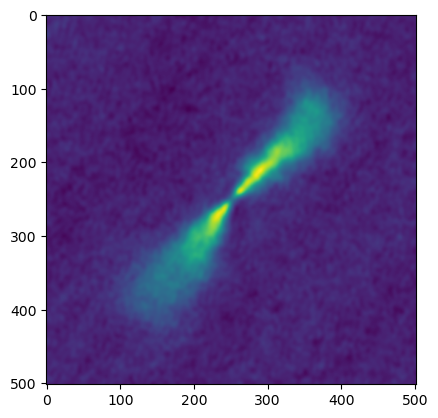

In [14]:
plt.imshow(data[19])

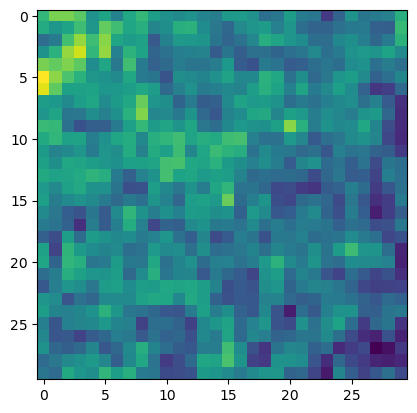

In [16]:
plt.imshow(data[19,0:150:5,0:150:5])

In [51]:
np.std(data[:,0:20:5,0::5])

np.float32(0.0018723955)